# 04 交割月份成交量分布与归一化 KL 集中度

本 Notebook 复现论文 Figures 2–3：先展示 Nickel 与 Steel Rebar 在 2016、2018、2021 年的交割月份成交量分布，再计算六品种 2012–2021 年相对均匀分布的归一化 Kullback-Leibler（KL）集中度。

数据只从正式 silver 湖仓读取；所有结果仅保存在 Notebook 输出中，不写入 silver、gold 或其他数据文件。

## 在做什么

同一品种在一个交易年度内可能同时交易多个交割月份。本项把所有具体合约按 `delist_date` 的月份聚合，计算每个交割月份占该品种年度成交量的比例。

- Figure 2 风格图用极坐标比较 NI 与 RB 在三个代表年份的月份分布。
- Figure 3 风格图把整个分布压缩成一个年度指标：0 表示成交量在有效交割月份间完全均匀，1 表示全部集中于一个月份。

## 经济意义

成交量分散到更多交割月份，意味着套保者和投资者在非主流月份也更可能获得可交易的流动性，期限选择更丰富。归一化 KL 越低，年度成交越分散；越高，成交越集中于少数基准月份。

“更分散”不等于“总成交量更大”，也不自动代表市场质量全面提高。品种的交割制度、产业季节性和标准合约月份会自然造成集中，因此 KL 主要适合比较同一品种随时间的变化。

## 论文口径

给定某品种在一年内有 \(N\) 个实际成交的交割月份，月份 \(T_k\) 的年度成交量和权重为：

$$
V(T_k)=\sum_t v(t,T_k), \qquad
w_k=\frac{V(T_k)}{\sum_{l=1}^{N}V(T_l)}.
$$

论文计算相对均匀分布的 KL：

$$
KL=\sum_{k=1}^{N}w_k\ln(w_kN),
$$

再除以 \(\ln(N)\)：

$$
KL_{\mathrm{normalized}}
=\frac{\sum_{k=1}^{N}w_k\ln(w_kN)}{\ln(N)}.
$$

均匀分布时为 0，单月完全集中时为 1。Figure 2 展示 NI、RB 的 2016、2018、2021 年月份分布；Figure 3 展示六品种 2012–2021 年的年度归一化 KL。

## 当前数据映射与适用边界

- 用合约日历权威 `delist_date.month` 表示交割月份，不解析合约代码。
- 统计年度是 `trading_date.year`；同一年度内到期年份不同、但交割月份相同的具体合约合并到一个月份桶。
- 只纳入 `has_market_data=true` 且成交量大于 0 的合约日。
- (N) 是该品种—年度中年度成交量大于 0 的交割月份数。零成交月份不进入 KL 的“实际成交月份”集合，但 Figure 2 仍补齐 01–12 月为零值以保持坐标一致。
- 当 (Nle1) 时 (ln(N)) 无法提供有效归一化，本 Notebook 不报告该年度 KL。
- 本样本的有效月份集合与论文 Table 1 的合约频率一致：RB/CU/NI/L 为 12 个月，M 为奇数月加 08、12，C 为奇数月。

## 代码步骤

1. 定位项目根目录并导入权威日线与合约日历 Schema。
2. 设置论文样本、Figure 2 年份和六品种。
3. 契约化读取成交量与 `delist_date`。
4. 折叠 Session、按唯一合约日连接并构造年度交割月份分布。
5. 绘制 Figure 2 风格极坐标图。
6. 逐品种—年度计算归一化 KL。
7. 绘制 Figure 3 风格六面板年度曲线并逐组人工复算。

## 第 1 步：环境、根目录和权威 Schema

In [1]:
from __future__ import annotations

import pathlib
import sys
from datetime import date

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

PROJECT_ROOT = candidate_root

from config.data_contracts import (  # noqa: E402
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_DAILY_SCHEMA,
    arrow_to_pandas,
)
from config.settings import settings  # noqa: E402

print(f"project_root: {PROJECT_ROOT}")
print(f"python: {sys.executable}")
print(
    "schema_tables: "
    f"{FUTURES_DAILY_SCHEMA.metadata[b'table_name'].decode('utf-8')}, "
    f"{FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata[b'table_name'].decode('utf-8')}"
)

project_root: E:\Latitude_Analytics_v2
python: E:\anaconda3\envs\latitude\python.exe
schema_tables: fact_futures_daily, dim_futures_contract_calendar


## 第 2 步：设置论文样本与图表参数

日期参数可扩展到湖仓历史；Figure 2 的代表年份单独配置。论文样本内的预期交割月份集合只用于验证数据映射，不参与 KL 数值计算。

In [2]:
PAPER_START_DATE = date(2012, 1, 1)
PAPER_END_DATE = date(2021, 12, 31)
ANALYSIS_START_DATE: date | None = PAPER_START_DATE
ANALYSIS_END_DATE: date | None = PAPER_END_DATE
FIGURE2_YEARS = [2016, 2018, 2021]
FIGURE2_PRODUCT_CODES = ["NI", "RB"]

PRODUCTS = [
    {"exchange_code": "XSGE", "underlying_code": "RB", "label": "Steel Rebar"},
    {"exchange_code": "XSGE", "underlying_code": "CU", "label": "Copper"},
    {"exchange_code": "XSGE", "underlying_code": "NI", "label": "Nickel"},
    {"exchange_code": "XDCE", "underlying_code": "M", "label": "Soybean Meal"},
    {"exchange_code": "XDCE", "underlying_code": "L", "label": "Plastic"},
    {"exchange_code": "XDCE", "underlying_code": "C", "label": "Corn"},
]
PRODUCT_KEYS = [
    (product["exchange_code"], product["underlying_code"])
    for product in PRODUCTS
]
PRODUCT_BY_CODE = {
    product["underlying_code"]: product
    for product in PRODUCTS
}
PRODUCT_LABEL_BY_KEY = {
    (product["exchange_code"], product["underlying_code"]): product["label"]
    for product in PRODUCTS
}

EXPECTED_PAPER_DELIVERY_MONTHS_BY_PRODUCT = {
    "RB": tuple(range(1, 13)),
    "CU": tuple(range(1, 13)),
    "NI": tuple(range(1, 13)),
    "M": (1, 3, 5, 7, 8, 9, 11, 12),
    "L": tuple(range(1, 13)),
    "C": (1, 3, 5, 7, 9, 11),
}
FIGURE2_YEAR_COLORS = {
    2016: "#3568B8",
    2018: "#E4572E",
    2021: "#F3A712",
}

display(pd.DataFrame(PRODUCTS))
print(f"analysis_dates: {ANALYSIS_START_DATE} to {ANALYSIS_END_DATE}")
print(f"figure2_years: {FIGURE2_YEARS}")

,exchange_code,underlying_code,label
0,XSGE,RB,Steel Rebar
1,XSGE,CU,Copper
2,XSGE,NI,Nickel
3,XDCE,M,Soybean Meal
4,XDCE,L,Plastic
5,XDCE,C,Corn


analysis_dates: 2012-01-01 to 2021-12-31
figure2_years: [2016, 2018, 2021]


## 第 3 步：契约化读取日线和合约日历

从权威 Schema 取得表名、分区和字段类型。查询只下推六品种与研究日期，不扫描其他研究宇宙。

In [3]:
daily_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_DAILY_SCHEMA.metadata or {}).items()
}
calendar_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata or {}).items()
}
daily_path = settings.futures_lake_root / "silver" / daily_metadata["table_name"]
calendar_path = settings.futures_lake_root / "silver" / calendar_metadata["table_name"]
for table_path in [daily_path, calendar_path]:
    if not table_path.exists():
        raise FileNotFoundError(f"silver 表不存在：{table_path}")

daily_partition_columns = daily_metadata["partition_columns"].split(",")
calendar_partition_columns = calendar_metadata["partition_columns"].split(",")
daily_partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_DAILY_SCHEMA.field(column_name).type)
        for column_name in daily_partition_columns
    ]
)
calendar_partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name).type)
        for column_name in calendar_partition_columns
    ]
)
daily_dataset = ds.dataset(
    daily_path,
    format="parquet",
    partitioning=ds.partitioning(daily_partitioning_schema, flavor="hive"),
)
calendar_dataset = ds.dataset(
    calendar_path,
    format="parquet",
    partitioning=ds.partitioning(calendar_partitioning_schema, flavor="hive"),
)

daily_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "volume",
    "has_market_data",
]
calendar_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delist_date",
]
daily_required_schema = pa.schema(
    [FUTURES_DAILY_SCHEMA.field(column_name) for column_name in daily_columns]
)
calendar_required_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in calendar_columns
    ]
)
for required_schema, source_dataset in [
    (daily_required_schema, daily_dataset),
    (calendar_required_schema, calendar_dataset),
]:
    for expected_field in required_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if actual_field.type != expected_field.type:
            raise TypeError(
                f"字段 {expected_field.name} 类型不匹配："
                f"期望 {expected_field.type}，实际 {actual_field.type}"
            )

product_filter = None
for exchange_code, underlying_code in PRODUCT_KEYS:
    current_product_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
    )
    product_filter = (
        current_product_filter
        if product_filter is None
        else product_filter | current_product_filter
    )

filter_expression = product_filter
if ANALYSIS_START_DATE is not None:
    filter_expression = filter_expression & (
        ds.field("trading_date") >= pa.scalar(ANALYSIS_START_DATE)
    )
if ANALYSIS_END_DATE is not None:
    filter_expression = filter_expression & (
        ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE)
    )

selected_daily_table = daily_dataset.to_table(
    columns=daily_columns,
    filter=filter_expression,
)
selected_calendar_table = calendar_dataset.to_table(
    columns=calendar_columns,
    filter=filter_expression,
)
source_daily_df = arrow_to_pandas(selected_daily_table, daily_required_schema)
source_calendar_session_df = arrow_to_pandas(
    selected_calendar_table,
    calendar_required_schema,
)
for source_df in [source_daily_df, source_calendar_session_df]:
    source_df["trading_date"] = pd.to_datetime(source_df["trading_date"])
source_calendar_session_df["delist_date"] = pd.to_datetime(
    source_calendar_session_df["delist_date"]
)
source_daily_df["volume"] = pd.to_numeric(
    source_daily_df["volume"], errors="coerce"
).astype(float)

print(f"daily_path: {daily_path}")
print(f"calendar_path: {calendar_path}")
print(f"daily_rows: {len(source_daily_df):,}")
print(f"calendar_session_rows: {len(source_calendar_session_df):,}")

daily_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\fact_futures_daily
calendar_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\dim_futures_contract_calendar
daily_rows: 141,254
calendar_session_rows: 513,206


## 第 4 步：连接交割月份并构造年度分布

同一合约日可能在合约日历中对应多个 Session。先确认这些 Session 的 `delist_date` 一致，再折叠为唯一合约日并与日线一对一连接。最后把具体合约成交量汇总到交易年度—交割月份。

In [4]:
contract_day_keys = [
    "exchange_code",
    "underlying_code",
    "contract_code",
    "trading_date",
]
calendar_delist_count_df = (
    source_calendar_session_df.groupby(
        contract_day_keys,
        observed=True,
        dropna=False,
    )["delist_date"]
    .nunique(dropna=False)
    .reset_index(name="distinct_delist_dates")
)
calendar_delist_conflicts_df = calendar_delist_count_df.loc[
    calendar_delist_count_df["distinct_delist_dates"] != 1
]
if not calendar_delist_conflicts_df.empty:
    raise ValueError(
        "同一合约日存在缺失或冲突 delist_date："
        f"{len(calendar_delist_conflicts_df):,} 个键"
    )

contract_calendar_df = (
    source_calendar_session_df.sort_values(contract_day_keys)
    .drop_duplicates(contract_day_keys, keep="first")
    .reset_index(drop=True)
)
if source_daily_df.duplicated(contract_day_keys).any():
    raise AssertionError("日线事实表在连接键上存在重复")
if contract_calendar_df.duplicated(contract_day_keys).any():
    raise AssertionError("合约日历折叠后仍有重复键")

joined_contract_day_df = source_daily_df.merge(
    contract_calendar_df,
    on=contract_day_keys,
    how="left",
    validate="one_to_one",
    indicator=True,
)
unmatched_daily_df = joined_contract_day_df.loc[
    joined_contract_day_df["_merge"] != "both"
]
if not unmatched_daily_df.empty:
    raise ValueError(f"日线记录缺少合约日历匹配：{len(unmatched_daily_df):,} 行")
if (joined_contract_day_df["volume"].dropna() < 0).any():
    raise ValueError("来源日线存在负成交量")

market_delivery_df = joined_contract_day_df.loc[
    joined_contract_day_df["has_market_data"].fillna(False)
    & joined_contract_day_df["volume"].notna()
    & (joined_contract_day_df["volume"] > 0)
    & joined_contract_day_df["delist_date"].notna()
].copy()
if market_delivery_df.empty:
    raise ValueError("没有可用于交割月份分布的正成交量记录")
if not np.isfinite(market_delivery_df["volume"].to_numpy(dtype=float)).all():
    raise ValueError("有效成交量包含非有限值")

market_delivery_df["trading_year"] = (
    market_delivery_df["trading_date"].dt.year.astype("int64")
)
market_delivery_df["delivery_month"] = (
    market_delivery_df["delist_date"].dt.month.astype("int64")
)
if not market_delivery_df["delivery_month"].between(1, 12).all():
    raise ValueError("交割月份不在 1–12")

annual_month_volume_df = (
    market_delivery_df.groupby(
        [
            "exchange_code",
            "underlying_code",
            "trading_year",
            "delivery_month",
        ],
        observed=True,
        as_index=False,
    )
    .agg(volume=("volume", "sum"))
)
month_grid = pd.DataFrame({"delivery_month": np.arange(1, 13, dtype=int)})
annual_distribution_parts = []
for product in PRODUCTS:
    product_key = (product["exchange_code"], product["underlying_code"])
    product_years = sorted(
        annual_month_volume_df.loc[
            (annual_month_volume_df["exchange_code"] == product_key[0])
            & (annual_month_volume_df["underlying_code"] == product_key[1]),
            "trading_year",
        ].unique()
    )
    for trading_year in product_years:
        product_year_month_volume_df = annual_month_volume_df.loc[
            (annual_month_volume_df["exchange_code"] == product_key[0])
            & (annual_month_volume_df["underlying_code"] == product_key[1])
            & (annual_month_volume_df["trading_year"] == trading_year),
            ["delivery_month", "volume"],
        ]
        completed_distribution_df = month_grid.merge(
            product_year_month_volume_df,
            on="delivery_month",
            how="left",
            validate="one_to_one",
        )
        completed_distribution_df["volume"] = (
            completed_distribution_df["volume"].fillna(0.0)
        )
        annual_total_volume = completed_distribution_df["volume"].sum()
        if not np.isfinite(annual_total_volume) or annual_total_volume <= 0:
            raise ValueError(f"年度成交量无效：{product_key}, {trading_year}")
        completed_distribution_df["volume_share"] = (
            completed_distribution_df["volume"] / annual_total_volume
        )
        completed_distribution_df["exchange_code"] = product_key[0]
        completed_distribution_df["underlying_code"] = product_key[1]
        completed_distribution_df["label"] = product["label"]
        completed_distribution_df["trading_year"] = int(trading_year)
        annual_distribution_parts.append(completed_distribution_df)

annual_month_distribution_df = pd.concat(
    annual_distribution_parts,
    ignore_index=True,
)
annual_coverage_df = (
    market_delivery_df.groupby(
        ["exchange_code", "underlying_code", "trading_year"],
        observed=True,
        as_index=False,
    )
    .agg(
        positive_volume_contract_days=("contract_code", "size"),
        contracts=("contract_code", "nunique"),
        total_volume=("volume", "sum"),
        first_trading_date=("trading_date", "min"),
        last_trading_date=("trading_date", "max"),
        positive_delivery_months=("delivery_month", "nunique"),
    )
)
annual_coverage_df["label"] = annual_coverage_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[
        (row["exchange_code"], row["underlying_code"])
    ],
    axis=1,
)
product_coverage_summary_df = (
    annual_coverage_df.groupby(
        ["exchange_code", "underlying_code", "label"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_year=("trading_year", "min"),
        last_year=("trading_year", "max"),
        years=("trading_year", "size"),
        contracts=("contracts", "sum"),
        positive_volume_contract_days=("positive_volume_contract_days", "sum"),
        total_volume=("total_volume", "sum"),
        min_positive_delivery_months=("positive_delivery_months", "min"),
        max_positive_delivery_months=("positive_delivery_months", "max"),
    )
)
display(product_coverage_summary_df)
print(f"join_status: {joined_contract_day_df['_merge'].value_counts().to_dict()}")
print(f"calendar_delist_conflicts: {len(calendar_delist_conflicts_df):,}")
print(f"positive_volume_contract_days: {len(market_delivery_df):,}")
print(f"annual_month_distribution_rows: {len(annual_month_distribution_df):,}")

,exchange_code,underlying_code,label,first_year,last_year,years,contracts,positive_volume_contract_days,total_volume,min_positive_delivery_months,max_positive_delivery_months
0,XDCE,C,Corn,2012,2021,10,120,13875,1.403286e+09,6,6
1,XDCE,L,Plastic,2012,2021,10,230,14676,1.430923e+09,12,12
2,XDCE,M,Soybean Meal,2012,2021,10,160,18548,5.016842e+09,8,8
3,XSGE,CU,Copper,2012,2021,10,240,29089,1.110549e+09,12,12
4,XSGE,NI,Nickel,2015,2021,7,161,16984,1.378445e+09,12,12
5,XSGE,RB,Steel Rebar,2012,2021,10,240,27990,9.133473e+09,12,12


join_status: {'both': 141254, 'left_only': 0, 'right_only': 0}
calendar_delist_conflicts: 0
positive_volume_contract_days: 121,162
annual_month_distribution_rows: 684


## 第 5 步：绘制 Figure 2 风格交割月份分布

每个极坐标面板补齐 01–12 月。半径是该月份占品种年度成交量的百分比；颜色表示年份。论文默认展示 NI 与 RB 的 2016、2018、2021 年。

01    02    03     04     05     06     07    08     09     10     11    12
underlying_code label       trading_year                                                                                
NI              Nickel      2016          28.82  0.01  0.01   0.00  33.88   0.01   0.01  0.01  37.25   0.01   0.00  0.01
                            2018          14.19  0.00  1.34   0.23  22.04   0.01  26.33  0.00  17.59   0.01  18.24  0.01
                            2021           1.60  5.87  8.91  10.11   1.74  22.90  10.85  7.11   9.51   9.29   7.07  5.04
RB              Steel Rebar 2016          21.80  0.03  0.01   0.01  23.48   0.02   0.01  0.00   0.13  54.51   0.01  0.01
                            2018          31.07  0.01  0.01   0.00  30.12   0.01   0.00  0.00   0.06  38.70   0.01  0.00
                            2021          32.82  0.26  0.25   0.11  31.31   0.33   0.34  0.15   0.39  33.40   0.28  0.37

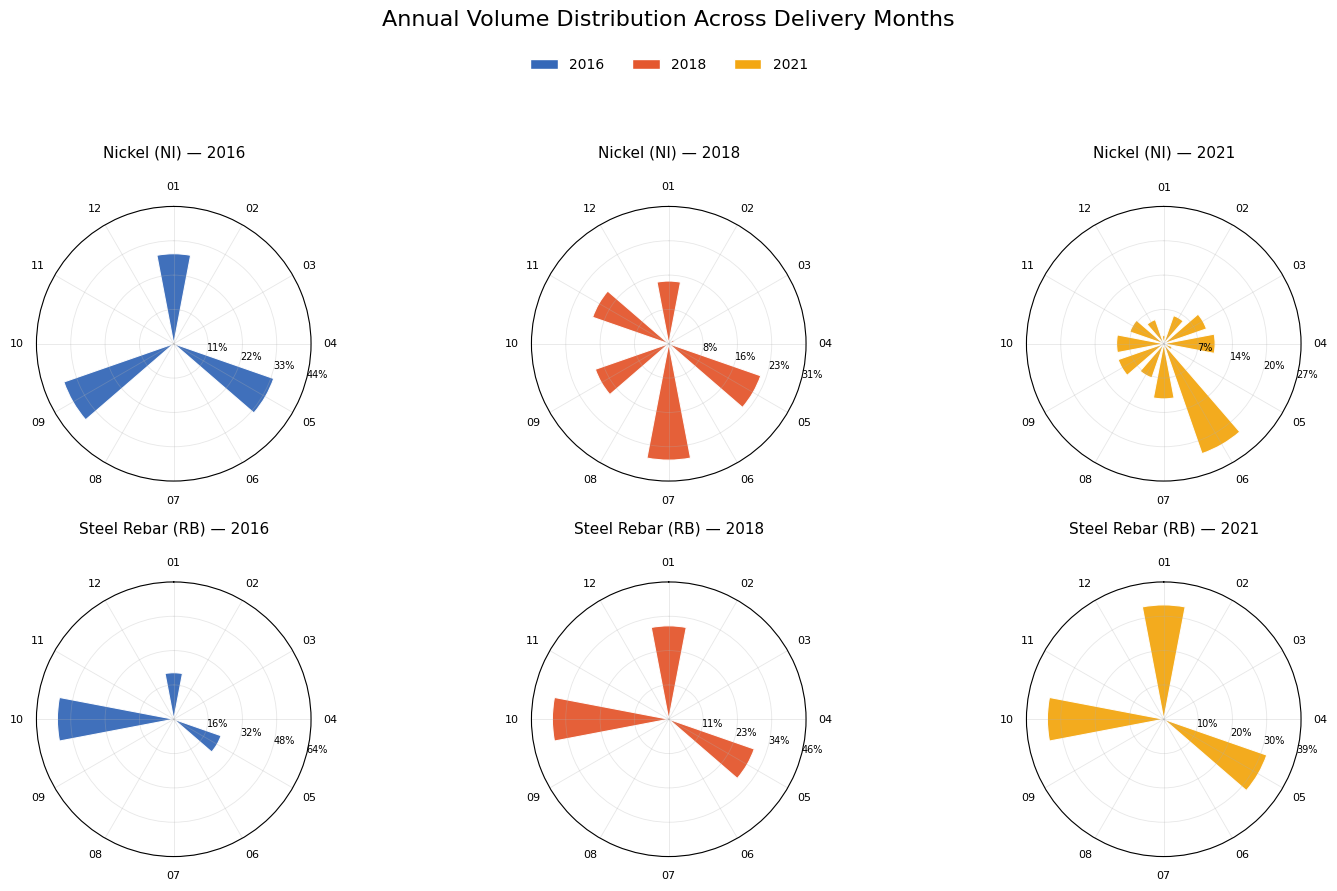

In [5]:
figure2_distribution_df = annual_month_distribution_df.loc[
    annual_month_distribution_df["underlying_code"].isin(FIGURE2_PRODUCT_CODES)
    & annual_month_distribution_df["trading_year"].isin(FIGURE2_YEARS)
].copy()
expected_figure2_groups = {
    (product_code, trading_year)
    for product_code in FIGURE2_PRODUCT_CODES
    for trading_year in FIGURE2_YEARS
}
actual_figure2_groups = set(
    figure2_distribution_df[["underlying_code", "trading_year"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
if actual_figure2_groups != expected_figure2_groups:
    raise AssertionError(
        "Figure 2 品种—年份覆盖不完整："
        f"缺少 {sorted(expected_figure2_groups - actual_figure2_groups)}"
    )

figure2_table_df = (
    figure2_distribution_df.assign(
        volume_share_pct=figure2_distribution_df["volume_share"] * 100
    )
    .pivot(
        index=["underlying_code", "label", "trading_year"],
        columns="delivery_month",
        values="volume_share_pct",
    )
    .reindex(
        pd.MultiIndex.from_tuples(
            [
                (
                    product_code,
                    PRODUCT_BY_CODE[product_code]["label"],
                    trading_year,
                )
                for product_code in FIGURE2_PRODUCT_CODES
                for trading_year in FIGURE2_YEARS
            ],
            names=["underlying_code", "label", "trading_year"],
        )
    )
    .reindex(columns=range(1, 13))
)
figure2_table_df.columns = [f"{month:02d}" for month in figure2_table_df.columns]
display(figure2_table_df.round(2))

theta = np.linspace(0, 2 * np.pi, 12, endpoint=False)
bar_width = 2 * np.pi / 12 * 0.72
figure2, axes2 = plt.subplots(
    len(FIGURE2_PRODUCT_CODES),
    len(FIGURE2_YEARS),
    figsize=(15, 9),
    subplot_kw={"projection": "polar"},
)
for row_index, product_code in enumerate(FIGURE2_PRODUCT_CODES):
    product = PRODUCT_BY_CODE[product_code]
    for column_index, trading_year in enumerate(FIGURE2_YEARS):
        axis = axes2[row_index, column_index]
        product_year_distribution_df = figure2_distribution_df.loc[
            (figure2_distribution_df["underlying_code"] == product_code)
            & (figure2_distribution_df["trading_year"] == trading_year)
        ].sort_values("delivery_month")
        volume_share_pct = (
            product_year_distribution_df["volume_share"].to_numpy(dtype=float)
            * 100
        )
        if len(volume_share_pct) != 12:
            raise AssertionError(
                f"Figure 2 月份桶不是 12：{product_code}, {trading_year}"
            )

        axis.bar(
            theta,
            volume_share_pct,
            width=bar_width,
            color=FIGURE2_YEAR_COLORS[trading_year],
            edgecolor="white",
            linewidth=0.8,
            alpha=0.95,
        )
        axis.set_theta_zero_location("N")
        axis.set_theta_direction(-1)
        axis.set_xticks(theta)
        axis.set_xticklabels(
            [f"{month:02d}" for month in range(1, 13)],
            fontsize=8,
        )
        radial_upper_pct = max(5.0, float(volume_share_pct.max()) * 1.18)
        axis.set_ylim(0, radial_upper_pct)
        axis.set_yticks(
            np.linspace(radial_upper_pct / 4, radial_upper_pct, 4)
        )
        axis.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        axis.set_rlabel_position(105)
        axis.tick_params(axis="y", labelsize=7)
        axis.grid(alpha=0.3, linewidth=0.6)
        axis.set_title(
            f"{product['label']} ({product_code}) — {trading_year}",
            fontsize=11,
            pad=18,
        )

figure2.suptitle(
    "Annual Volume Distribution Across Delivery Months",
    fontsize=16,
    y=0.995,
)
figure2.tight_layout(rect=(0, 0.01, 1, 0.90))
figure2_legend = figure2.legend(
    handles=[
        Patch(
            facecolor=FIGURE2_YEAR_COLORS[trading_year],
            edgecolor="white",
            label=str(trading_year),
        )
        for trading_year in FIGURE2_YEARS
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=len(FIGURE2_YEARS),
    frameon=False,
)
plt.show()

## 第 6 步：计算归一化 KL 集中度

对每个品种—年度只保留年度成交量为正的月份，直接按论文公式计算。输出值乘 100 后可与论文 Figure 3 的百分比纵轴比较；数值本身仍保留在 0–1。

In [6]:
kl_records = []
for (
    exchange_code,
    underlying_code,
    trading_year,
), product_year_distribution_df in annual_month_distribution_df.groupby(
    ["exchange_code", "underlying_code", "trading_year"],
    observed=True,
):
    positive_month_df = product_year_distribution_df.loc[
        product_year_distribution_df["volume"] > 0
    ].sort_values("delivery_month")
    effective_delivery_month_count = len(positive_month_df)
    normalized_kl = np.nan
    if effective_delivery_month_count > 1:
        weights = positive_month_df["volume_share"].to_numpy(dtype=float)
        if not np.isclose(weights.sum(), 1.0, rtol=1e-12, atol=1e-12):
            raise AssertionError(
                f"正成交月份权重之和不为 1："
                f"{exchange_code}, {underlying_code}, {trading_year}"
            )
        kl_divergence = float(
            np.sum(
                weights
                * np.log(weights * effective_delivery_month_count)
            )
        )
        normalized_kl = (
            kl_divergence / np.log(effective_delivery_month_count)
        )

    kl_records.append(
        {
            "exchange_code": exchange_code,
            "underlying_code": underlying_code,
            "label": PRODUCT_LABEL_BY_KEY[
                (exchange_code, underlying_code)
            ],
            "trading_year": int(trading_year),
            "effective_delivery_month_count": (
                effective_delivery_month_count
            ),
            "normalized_kl": normalized_kl,
        }
    )

annual_kl_df = pd.DataFrame(kl_records).sort_values(
    ["exchange_code", "underlying_code", "trading_year"]
).reset_index(drop=True)
annual_kl_df["normalized_kl_pct"] = annual_kl_df["normalized_kl"] * 100

kl_table_df = (
    annual_kl_df.pivot(
        index="trading_year",
        columns="label",
        values="normalized_kl_pct",
    )
    .reindex(columns=[product["label"] for product in PRODUCTS])
)
display(kl_table_df.round(2))

kl_summary_df = (
    annual_kl_df.groupby(
        ["exchange_code", "underlying_code", "label"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_year=("trading_year", "min"),
        last_year=("trading_year", "max"),
        first_kl=("normalized_kl", "first"),
        last_kl=("normalized_kl", "last"),
        min_kl=("normalized_kl", "min"),
        max_kl=("normalized_kl", "max"),
    )
)
kl_summary_df["change_pct_points"] = (
    kl_summary_df["last_kl"] - kl_summary_df["first_kl"]
) * 100
for column_name in ["first_kl", "last_kl", "min_kl", "max_kl"]:
    kl_summary_df[f"{column_name}_pct"] = kl_summary_df[column_name] * 100
display(
    kl_summary_df[
        [
            "exchange_code",
            "underlying_code",
            "label",
            "first_year",
            "last_year",
            "first_kl_pct",
            "last_kl_pct",
            "min_kl_pct",
            "max_kl_pct",
            "change_pct_points",
        ]
    ]
)
print(f"annual_kl_rows: {len(annual_kl_df):,}")
print(
    "unreported_single_month_years: "
    f"{annual_kl_df['normalized_kl'].isna().sum():,}"
)

label,Steel Rebar,Copper,Nickel,Soybean Meal,Plastic,Corn
trading_year,,,,,,
2012,58.66,0.57,NaN,52.56,55.77,43.69
2013,57.74,6.31,NaN,47.70,57.76,40.18
2014,56.57,1.13,NaN,47.12,55.96,38.85
2015,55.77,0.65,51.96,48.11,56.10,42.24
2016,58.99,1.68,55.79,52.21,56.80,45.23
2017,57.34,0.32,55.69,47.43,55.82,40.17
2018,55.69,0.33,33.49,34.83,55.95,19.92
2019,55.72,0.26,7.18,37.18,56.73,22.17
2020,52.85,0.78,8.54,32.00,43.47,22.19


,exchange_code,underlying_code,label,first_year,last_year,first_kl_pct,last_kl_pct,min_kl_pct,max_kl_pct,change_pct_points
0,XDCE,C,Corn,2012,2021,43.689971,12.963224,12.963224,45.228554,-30.726747
1,XDCE,L,Plastic,2012,2021,55.767834,38.215294,38.215294,57.757839,-17.552540
2,XDCE,M,Soybean Meal,2012,2021,52.559415,28.754438,28.754438,52.559415,-23.804977
3,XSGE,CU,Copper,2012,2021,0.570047,0.889798,0.256396,6.308329,0.319751
4,XSGE,NI,Nickel,2015,2021,51.961969,7.478696,7.178850,55.793296,-44.483273
5,XSGE,RB,Steel Rebar,2012,2021,58.656780,50.089781,50.089781,58.985583,-8.566999


annual_kl_rows: 57
unreported_single_month_years: 0


## 第 7 步：绘制 Figure 3 风格年度 KL 曲线

六个面板各自保留适合自身波动范围的纵轴，避免 CU 的低集中度被 RB/L 的高集中度压平。所有纵轴仍统一表示归一化 KL 百分比，越低代表交割月份间越分散。

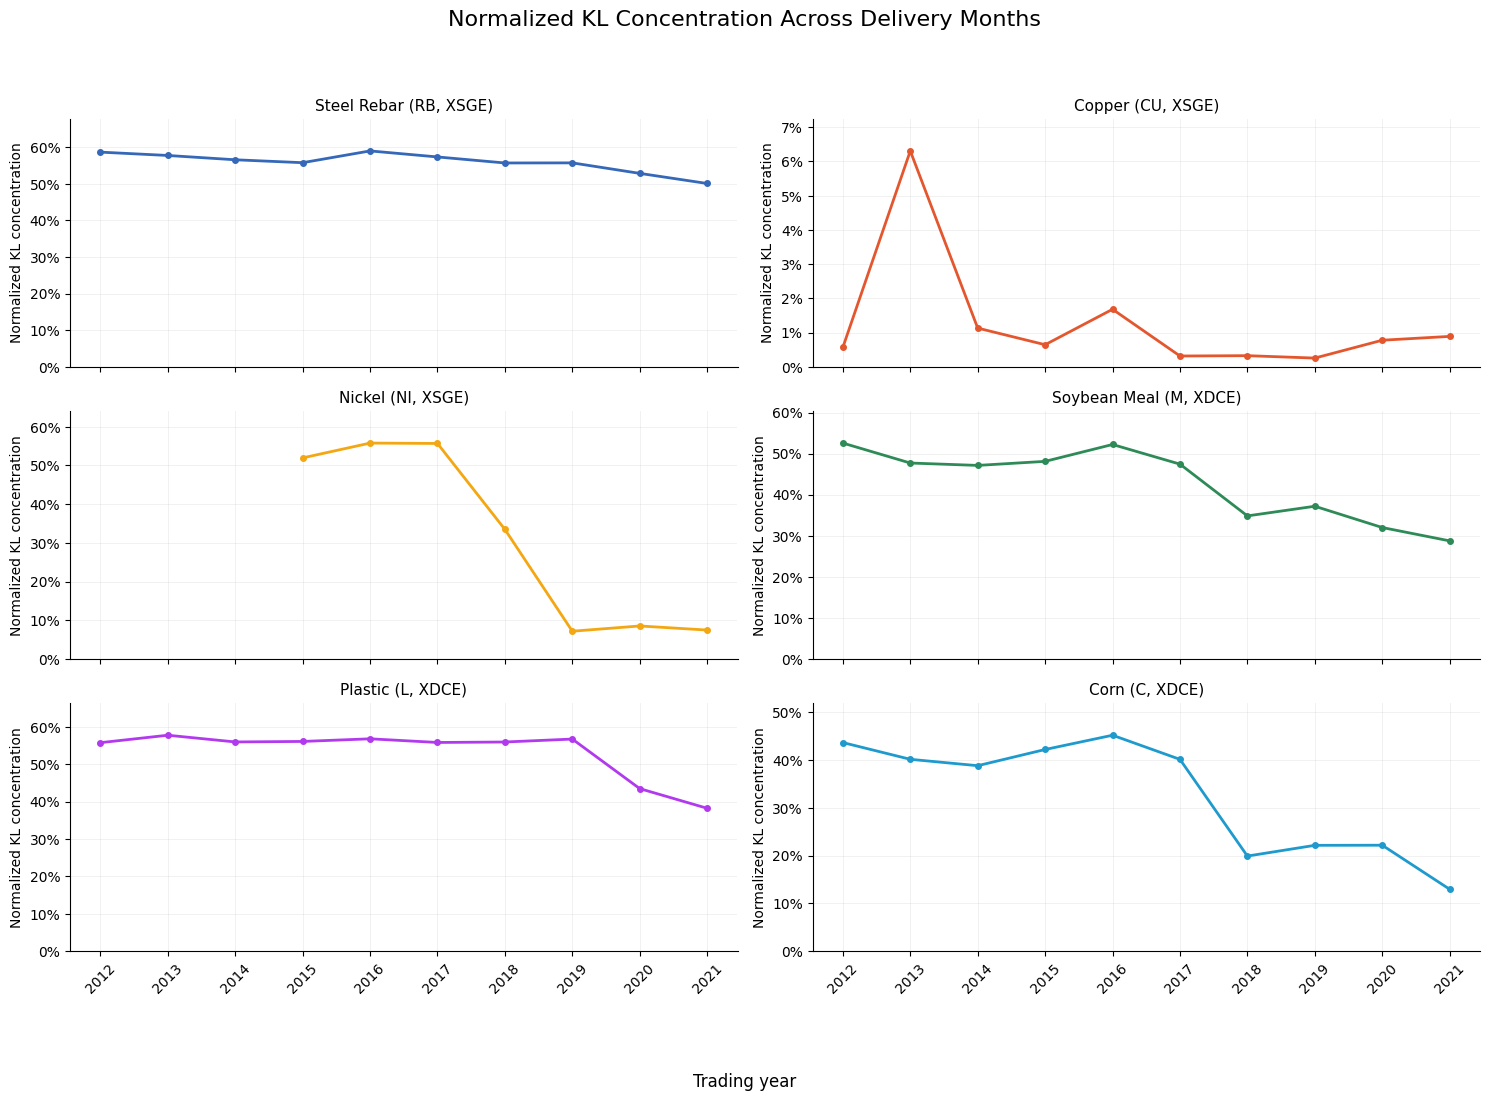

In [7]:
PRODUCT_COLORS = {
    ("XSGE", "RB"): "#3568B8",
    ("XSGE", "CU"): "#E4572E",
    ("XSGE", "NI"): "#F3A712",
    ("XDCE", "M"): "#2E8B57",
    ("XDCE", "L"): "#B23AEE",
    ("XDCE", "C"): "#1E9ACD",
}
analysis_years = sorted(annual_kl_df["trading_year"].unique())

figure3, axes3 = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
for axis, product in zip(axes3.flat, PRODUCTS):
    product_key = (product["exchange_code"], product["underlying_code"])
    product_kl_df = annual_kl_df.loc[
        (annual_kl_df["exchange_code"] == product_key[0])
        & (annual_kl_df["underlying_code"] == product_key[1])
    ].sort_values("trading_year")
    reported_product_kl_df = product_kl_df.dropna(
        subset=["normalized_kl"]
    )
    if reported_product_kl_df.empty:
        raise AssertionError(f"Figure 3 品种没有可报告 KL：{product_key}")

    axis.plot(
        reported_product_kl_df["trading_year"],
        reported_product_kl_df["normalized_kl_pct"],
        color=PRODUCT_COLORS[product_key],
        linewidth=2.0,
        marker="o",
        markersize=4,
    )
    upper_limit_pct = max(
        5.0,
        float(reported_product_kl_df["normalized_kl_pct"].max()) * 1.15,
    )
    axis.set_ylim(0, upper_limit_pct)
    axis.set_title(
        f"{product['label']} ({product['underlying_code']}, {product['exchange_code']})",
        fontsize=11,
    )
    axis.set_ylabel("Normalized KL concentration")
    axis.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    axis.set_xticks(analysis_years)
    axis.tick_params(axis="x", rotation=45)
    axis.grid(alpha=0.2, linewidth=0.6)
    axis.spines[["top", "right"]].set_visible(False)

figure3.suptitle(
    "Normalized KL Concentration Across Delivery Months",
    fontsize=16,
    y=0.995,
)
figure3.supxlabel("Trading year", y=0.012)
figure3.tight_layout(rect=(0, 0.055, 1, 0.96))
plt.show()

## 验证

逐个品种—年度从年度月份成交量重新计算权重和 KL；同时验证概率和、0–1 边界、论文样本的合约月份频率、NI 上市时间，以及 Figures 2–3 的面板、月份柱和曲线。

In [8]:
validated_product_years = 0
for annual_kl_row in annual_kl_df.itertuples(index=False):
    product_year_month_volume_df = annual_month_volume_df.loc[
        (annual_month_volume_df["exchange_code"] == annual_kl_row.exchange_code)
        & (
            annual_month_volume_df["underlying_code"]
            == annual_kl_row.underlying_code
        )
        & (
            annual_month_volume_df["trading_year"]
            == annual_kl_row.trading_year
        )
        & (annual_month_volume_df["volume"] > 0)
    ].sort_values("delivery_month")
    manual_month_count = len(product_year_month_volume_df)
    manual_weights = (
        product_year_month_volume_df["volume"].to_numpy(dtype=float)
        / product_year_month_volume_df["volume"].sum()
    )
    if manual_month_count != annual_kl_row.effective_delivery_month_count:
        raise AssertionError("KL 有效月份数复算不一致")
    if manual_month_count <= 1:
        if not pd.isna(annual_kl_row.normalized_kl):
            raise AssertionError("单一有效月份年度不应报告 KL")
    else:
        manual_normalized_kl = float(
            np.sum(manual_weights * np.log(manual_weights * manual_month_count))
            / np.log(manual_month_count)
        )
        if not np.isclose(
            manual_normalized_kl,
            annual_kl_row.normalized_kl,
            rtol=1e-12,
            atol=1e-12,
        ):
            raise AssertionError(
                f"归一化 KL 复算不一致："
                f"{annual_kl_row.exchange_code}, "
                f"{annual_kl_row.underlying_code}, "
                f"{annual_kl_row.trading_year}"
            )

    product_year_distribution_df = annual_month_distribution_df.loc[
        (
            annual_month_distribution_df["exchange_code"]
            == annual_kl_row.exchange_code
        )
        & (
            annual_month_distribution_df["underlying_code"]
            == annual_kl_row.underlying_code
        )
        & (
            annual_month_distribution_df["trading_year"]
            == annual_kl_row.trading_year
        )
    ]
    if len(product_year_distribution_df) != 12:
        raise AssertionError("年度完整月份网格不是 12")
    if not np.isclose(
        product_year_distribution_df["volume_share"].sum(),
        1.0,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise AssertionError("年度月份成交量占比之和不为 1")
    validated_product_years += 1

reported_kl = annual_kl_df["normalized_kl"].dropna()
if not np.isfinite(reported_kl.to_numpy(dtype=float)).all():
    raise AssertionError("归一化 KL 包含非有限值")
if ((reported_kl < -1e-12) | (reported_kl > 1 + 1e-12)).any():
    raise AssertionError("归一化 KL 不在 [0, 1]")

available_product_keys = set(
    market_delivery_df[["exchange_code", "underlying_code"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
if available_product_keys != set(PRODUCT_KEYS):
    raise AssertionError("目标六品种覆盖不完整")

if (
    ANALYSIS_START_DATE == PAPER_START_DATE
    and ANALYSIS_END_DATE == PAPER_END_DATE
):
    for (
        underlying_code,
        trading_year,
    ), product_year_month_volume_df in annual_month_volume_df.groupby(
        ["underlying_code", "trading_year"],
        observed=True,
    ):
        actual_delivery_months = tuple(
            sorted(
                product_year_month_volume_df.loc[
                    product_year_month_volume_df["volume"] > 0,
                    "delivery_month",
                ].unique()
            )
        )
        expected_delivery_months = (
            EXPECTED_PAPER_DELIVERY_MONTHS_BY_PRODUCT[underlying_code]
        )
        if actual_delivery_months != expected_delivery_months:
            raise AssertionError(
                f"论文样本交割月份频率不一致："
                f"{underlying_code}, {trading_year}, "
                f"实际 {actual_delivery_months}, "
                f"期望 {expected_delivery_months}"
            )

nickel_first_trading_date = market_delivery_df.loc[
    (market_delivery_df["exchange_code"] == "XSGE")
    & (market_delivery_df["underlying_code"] == "NI"),
    "trading_date",
].min()
if nickel_first_trading_date < pd.Timestamp("2015-01-01"):
    raise AssertionError("NI 在 2015 年上市前出现正成交量记录")
if len(axes2.flat) != len(FIGURE2_PRODUCT_CODES) * len(FIGURE2_YEARS):
    raise AssertionError("Figure 2 面板数不是 6")
if any(len(axis.patches) != 12 for axis in axes2.flat):
    raise AssertionError("Figure 2 面板没有完整 12 个交割月份柱")
if len(figure2_legend.get_texts()) != len(FIGURE2_YEARS):
    raise AssertionError("Figure 2 图例没有覆盖三个年份")
if len(axes3.flat) != len(PRODUCTS):
    raise AssertionError("Figure 3 面板数不是 6")
if any(len(axis.lines) != 1 for axis in axes3.flat):
    raise AssertionError("Figure 3 存在空面板或多余曲线")
if validated_product_years != len(annual_kl_df):
    raise AssertionError("品种—年度验证数量不一致")

print(
    f"validation_ok: {len(available_product_keys)} products, "
    f"{validated_product_years} product-years, "
    f"{len(market_delivery_df):,} positive-volume contract-days, "
    f"{len(axes2.flat)} polar panels, "
    f"{len(axes3.flat)} KL panels"
)
print(f"nickel_first_trading_date: {nickel_first_trading_date.date()}")

validation_ok: 6 products, 57 product-years, 121,162 positive-volume contract-days, 6 polar panels, 6 KL panels
nickel_first_trading_date: 2015-03-27


## 如何解释结果

- Figure 2 中半径越长，表示该交割月份占年度成交量越高。NI 的月份分布随时间明显铺开；RB 仍主要集中在 01、05、10 月，但其他月份占比有所上升。
- Figure 3 中 KL 下降代表成交量相对均匀分布到更多有效交割月份。它衡量的是“集中度”，不是总流动性规模。
- RB、L 的合约设计允许每月交割，但产业交易长期集中于少数基准月，所以其 KL 明显高于 CU；C、M 的可用月份集合本来就不同，归一化使同品种跨年可比，但不能消除所有制度差异。
- NI 从 2015 年上市后才有年度值；上市初期样本长度与其他品种不同。
- 本结果与论文趋势的接近说明月份桶映射合理，但当前实现以湖仓 `delist_date` 表示交割月份，数值不被强制校准为论文图片。
- 这些趋势是描述性的，不能单独证明算法交易导致了交割月份流动性分散。